In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

In [2]:
sales_data = pd.read_csv('Financial-Analytics-data1.csv')
sales_data

,Name,Mar Cap - Crore,Sales Qtr - Crore,Market_Cap_Category,Sales_Qrt_Category
0,Reliance Inds.,583436.72,99810.00,Large Cap,High Sales
1,TCS,563709.84,30904.00,Large Cap,High Sales
2,HDFC Bank,482953.59,20581.27,Large Cap,High Sales
3,ITC,320985.27,9772.02,Large Cap,High Sales
4,H D F C,289497.37,16840.51,Large Cap,High Sales
...,...,...,...,...,...
454,Prime Focus,3031.50,609.61,Very Small Cap,Low Sales
455,Lak. Vilas Bank,3029.57,790.17,Very Small Cap,Low Sales
456,NOCIL,3026.26,249.27,Very Small Cap,Very Low Sales
457,Orient Cement,3024.32,511.53,Very Small Cap,Very Low Sales


In [3]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459 entries, 0 to 458
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Name                 459 non-null    object 
 1   Mar Cap - Crore      459 non-null    float64
 2   Sales Qtr - Crore    459 non-null    float64
 3   Market_Cap_Category  459 non-null    object 
 4   Sales_Qrt_Category   459 non-null    object 
dtypes: float64(2), object(3)
memory usage: 18.1+ KB


In [4]:
sales_data.describe()

,Mar Cap - Crore,Sales Qtr - Crore
count,459.000000,459.000000
mean,28870.974139,3807.789412
std,60557.081792,9989.449987
min,3017.070000,0.000000
25%,4942.815000,534.910000
50%,10442.090000,1137.170000
75%,24707.320000,2730.195000
max,583436.720000,110666.930000


In [5]:
sales_data.isnull().sum()

Name                   0
Mar Cap - Crore        0
Sales Qtr - Crore      0
Market_Cap_Category    0
Sales_Qrt_Category     0
dtype: int64

In [6]:
sales_data.dropna(inplace=True)

In [7]:
sales_data.duplicated().sum()

np.int64(0)

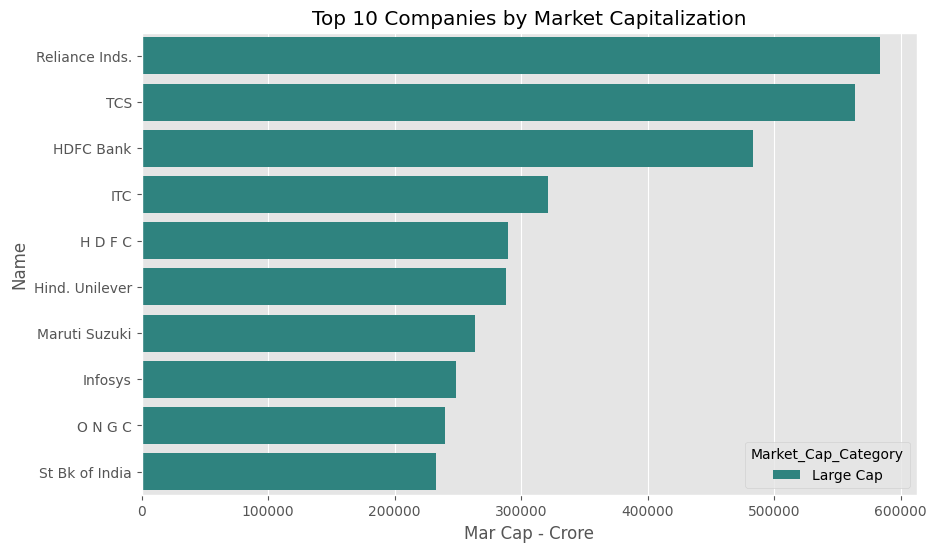

In [8]:
top_mc = sales_data.nlargest(10,'Mar Cap - Crore')

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_mc,
    x='Mar Cap - Crore',
    y='Name',
    palette='viridis',
    hue="Market_Cap_Category"
)

plt.title("Top 10 Companies by Market Capitalization")
plt.show()

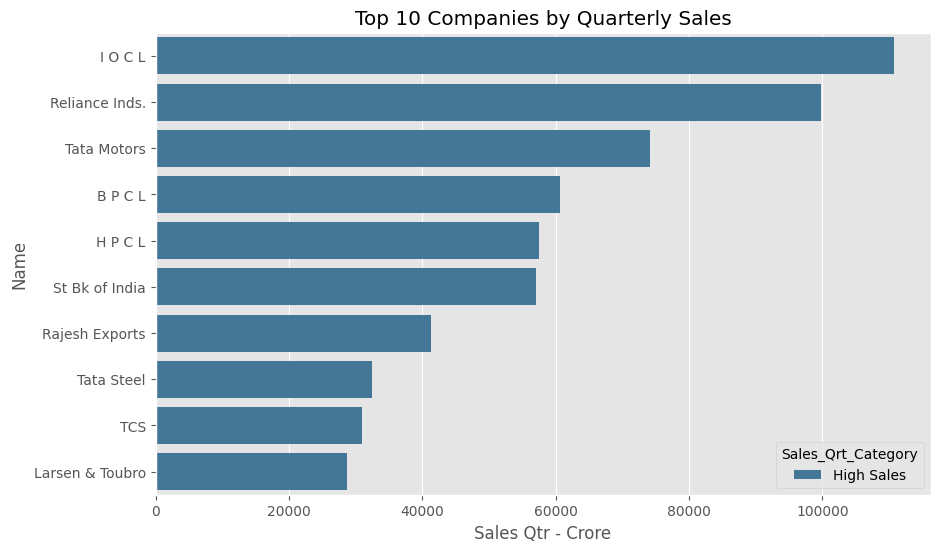

In [9]:
top_sales = sales_data.nlargest(10,'Sales Qtr - Crore')

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_sales,
    x='Sales Qtr - Crore',
    y='Name',
    palette="mako",
    hue="Sales_Qrt_Category"
)

plt.title("Top 10 Companies by Quarterly Sales")
plt.show()

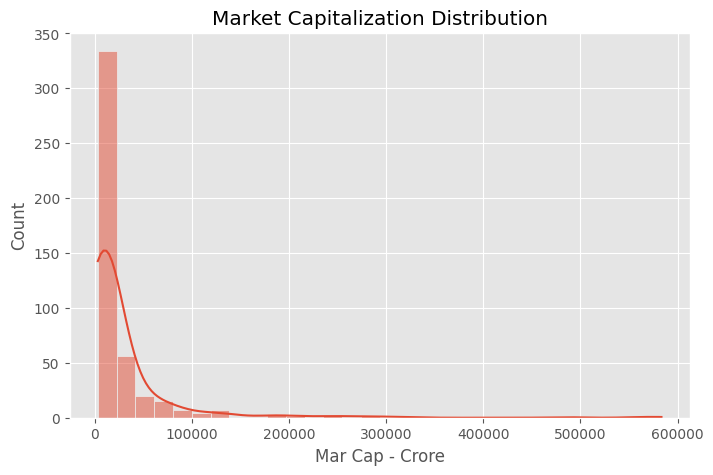

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    sales_data['Mar Cap - Crore'],
    bins=30,
    kde=True
)

plt.title("Market Capitalization Distribution")
plt.show()

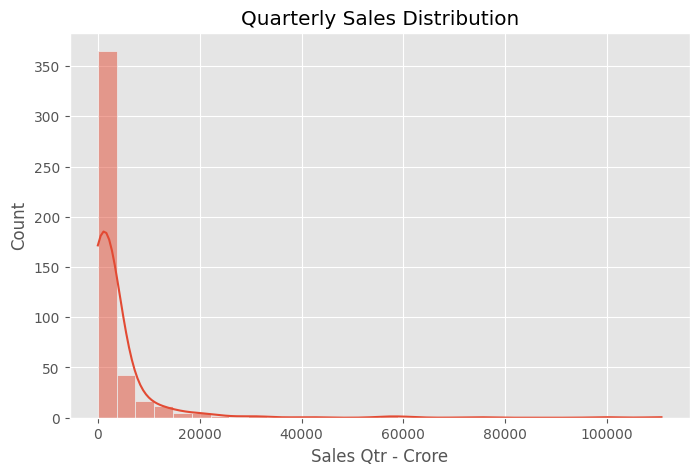

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    sales_data['Sales Qtr - Crore'],
    bins=30,
    kde=True
)

plt.title("Quarterly Sales Distribution")
plt.show()

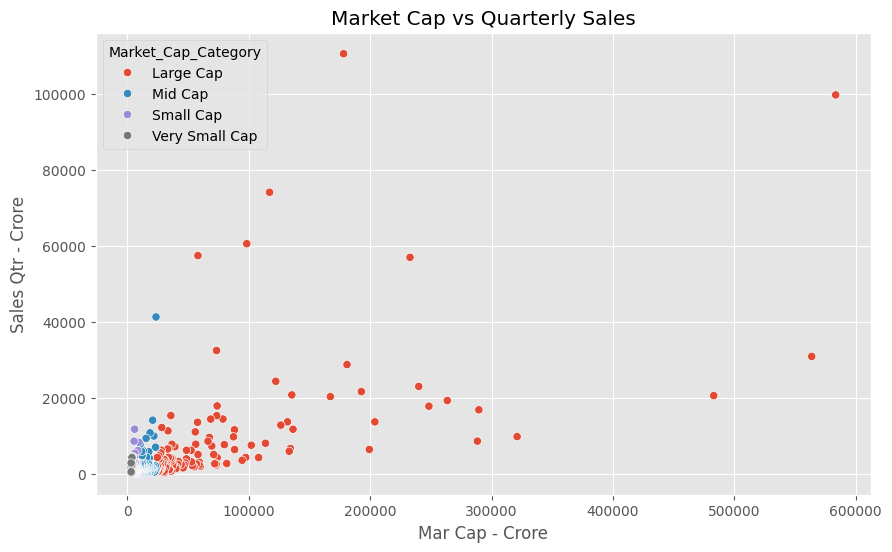

In [12]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sales_data,
    x='Mar Cap - Crore',
    y='Sales Qtr - Crore',
    hue='Market_Cap_Category'
)

plt.title("Market Cap vs Quarterly Sales")
plt.show()

In [13]:
corr = sales_data[['Mar Cap - Crore',
           'Sales Qtr - Crore']].corr()

corr

,Mar Cap - Crore,Sales Qtr - Crore
Mar Cap - Crore,1.000000,0.624409
Sales Qtr - Crore,0.624409,1.000000


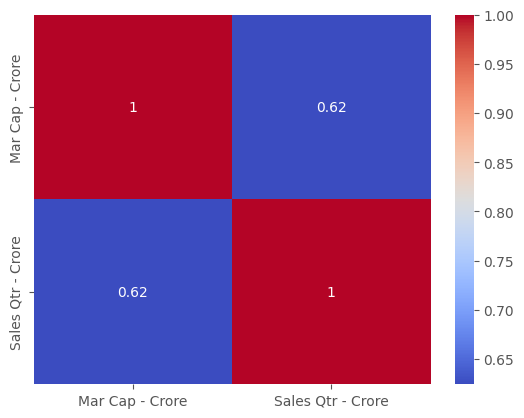

In [14]:
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

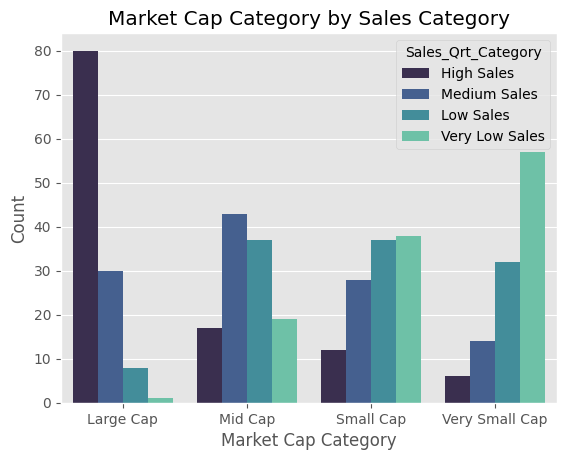

In [15]:
sales_data['Market_Cap_Category'].value_counts()

sns.countplot(
    data=sales_data,
    x='Market_Cap_Category',
    hue='Sales_Qrt_Category',
    palette='mako'
)

plt.xlabel("Market Cap Category")
plt.ylabel("Count")
plt.title("Market Cap Category by Sales Category")

plt.show()

In [16]:
avg_sales = sales_data.groupby(
    'Market_Cap_Category'
)['Sales Qtr - Crore'].mean()

avg_sales

Market_Cap_Category
Large Cap         10526.625378
Mid Cap            2267.054310
Small Cap          1285.352783
Very Small Cap      773.514220
Name: Sales Qtr - Crore, dtype: float64

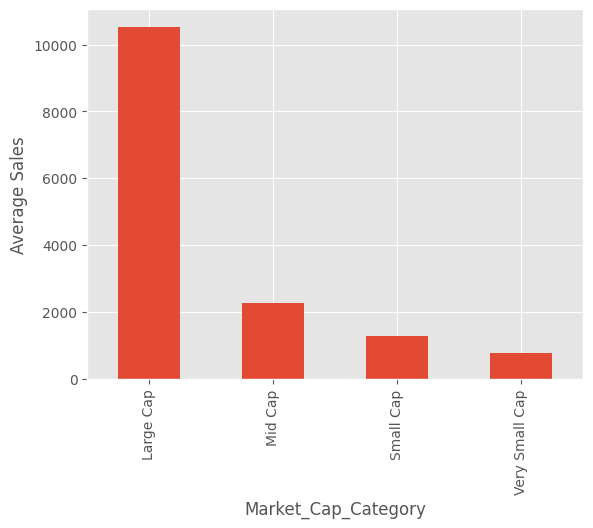

In [17]:
avg_sales.plot(
    kind='bar',
    
)

plt.ylabel("Average Sales")
plt.show()

In [18]:
sales_data['Sales_Efficiency'] = (
    sales_data['Sales Qtr - Crore']
    /
    sales_data['Mar Cap - Crore']
)

In [19]:
sales_data.nlargest(
    10,
    'Sales_Efficiency'
)[['Name','Sales_Efficiency']]

,Name,Sales_Efficiency
308,Redington India,1.989031
120,Rajesh Exports,1.757986
321,C P C L,1.582066
416,Corporation Bank,1.180653
419,Oriental Bank,1.159876
388,Andhra Bank,1.118510
384,Allahabad Bank,1.025796
53,H P C L,0.990341
458,Natl.Fertilizer,0.941559
304,Syndicate Bank,0.883214


In [20]:
print("Total Companies:",len(sales_data))

print("Average Market Cap:",
      round(sales_data['Mar Cap - Crore'].mean(),2))

print("Average Quarterly Sales:",
      round(sales_data['Sales Qtr - Crore'].mean(),2))

Total Companies: 459
Average Market Cap: 28870.97
Average Quarterly Sales: 3807.79
